# Decision Trees: Gini vs Entropy, Information Gain & Pruning (Wine Dataset)
Complete 10-step analysis including dataset loading, manual criterion calculations, model building, performance comparison, information gain visualization, and tree pruning.

In [2]:
# ---- Setup ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup complete.")

Setup complete.


## Part 1 — Dataset
Loading the Wine dataset and reviewing its shape and class distribution.

Dataset shape: (178, 15)

Class names: ['class_0' 'class_1' 'class_2']

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


Class distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


C:\Users\zarif\AppData\Local\Temp\ipykernel_26016\2935347829.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_name', palette='Set2')


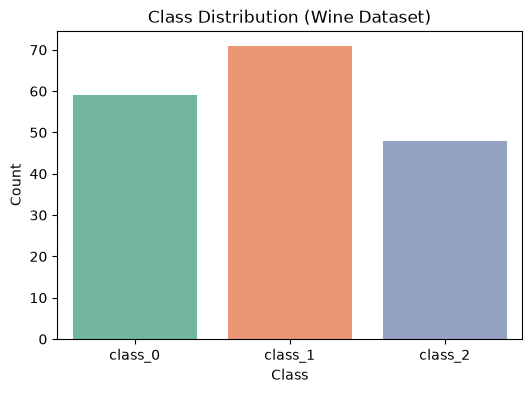

In [3]:
# Load the Wine dataset
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names
df = wine.frame.copy()
df['target_name'] = df['target'].map(dict(enumerate(class_names)))

print("Dataset shape:", df.shape)
print("\nClass names:", class_names)
print("\nFirst 5 rows:")
display(df.head())

# Check class distribution
print("Class distribution:")
print(df['target_name'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target_name', palette='Set2')
plt.title('Class Distribution (Wine Dataset)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

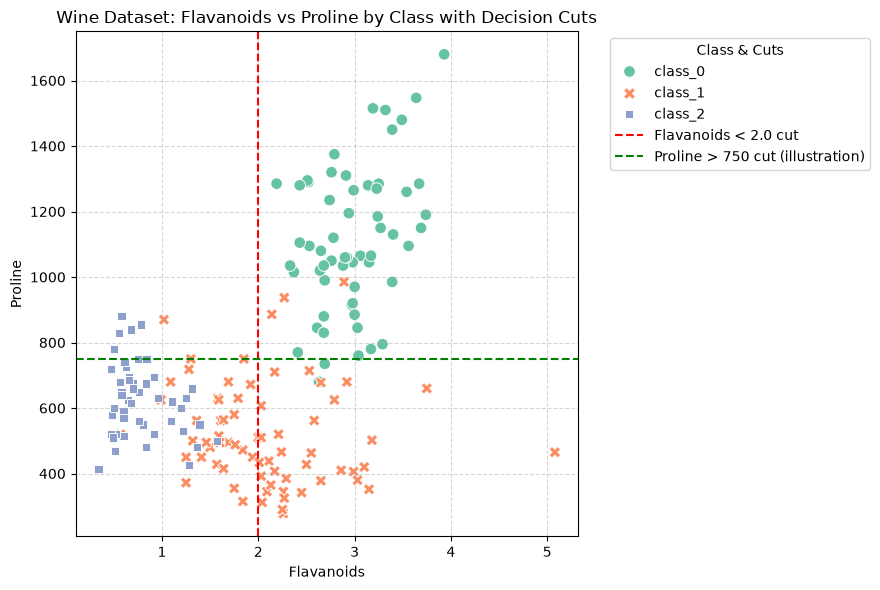

In [16]:
df = wine.frame.copy()
class_names = wine.target_names
df['target_name'] = df['target'].map(dict(enumerate(class_names)))

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='flavanoids',
    y='proline',
    hue='target_name',
    palette='Set2',
    style='target_name',
    s=70,
)

# Adding the requested reference lines/axes for cuts
plt.axvline(x=2.0, color='red', linestyle='--', label='Flavanoids < 2.0 cut')
plt.axhline(
    y=750.0, color='green', linestyle='--', label='Proline > 750 cut (illustration)'
)

plt.title('Wine Dataset: Flavanoids vs Proline by Class with Decision Cuts')
plt.xlabel('Flavanoids')
plt.ylabel('Proline')
plt.legend(title='Class & Cuts', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

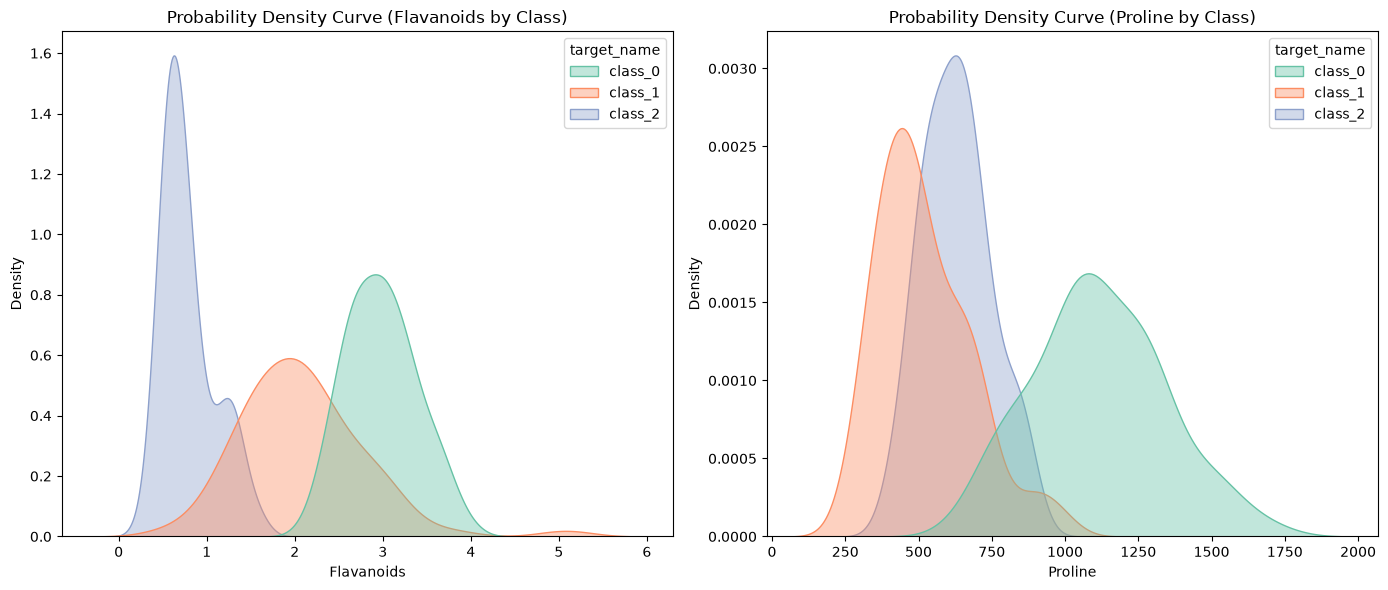

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Density curves for Flavanoids by class
sns.kdeplot(
    data=df,
    x='flavanoids',
    hue='target_name',
    palette='Set2',
    fill=True,
    common_norm=False,
    alpha=0.4,
    ax=axes[0],
)
axes[0].set_title('Probability Density Curve (Flavanoids by Class)')
axes[0].set_xlabel('Flavanoids')
axes[0].set_ylabel('Density')

# 2. Density curves for Proline by class
sns.kdeplot(
    data=df,
    x='proline',
    hue='target_name',
    palette='Set2',
    fill=True,
    common_norm=False,
    alpha=0.4,
    ax=axes[1],
)
axes[1].set_title('Probability Density Curve (Proline by Class)')
axes[1].set_xlabel('Proline')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

## Part 2 — Gini Impurity vs. Entropy
Manual calculations for both splitting criteria. Gini measures the probability of misclassification. Entropy measures the level of disorder (information gain relies on this).

In [5]:
# Manual Gini Impurity calculation
def gini_impurity(labels):
    labels = pd.Series(labels)
    probabilities = labels.value_counts(normalize=True)
    return 1 - np.sum(probabilities ** 2)

# Manual Entropy calculation
def entropy(labels):
    labels = pd.Series(labels)
    probabilities = labels.value_counts(normalize=True)
    return -np.sum(probabilities * np.log2(probabilities + 1e-9))

example = ['A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B']
print(f"Gini Impurity (Example) = {gini_impurity(example):.4f}")
print(f"Entropy (Example) = {entropy(example):.4f}\n")

print(f"Pure node Gini: {gini_impurity(['A', 'A', 'A', 'A']):.4f} | Pure node Entropy: {entropy(['A', 'A', 'A', 'A']):.4f}")
print(f"Balanced node Gini: {gini_impurity(['A', 'A', 'B', 'B']):.4f} | Balanced node Entropy: {entropy(['A', 'A', 'B', 'B']):.4f}")

Gini Impurity (Example) = 0.4800
Entropy (Example) = 0.9710

Pure node Gini: 0.0000 | Pure node Entropy: -0.0000
Balanced node Gini: 0.5000 | Balanced node Entropy: 1.0000


## Part 3 — Train-Test Split
Dividing the dataset. 70% used for training, 30% for testing.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (124, 13)
Testing data : (54, 13)


## Part 4 — Build the Decision Trees
Training two separate models using Gini Impurity and Entropy to compare their performance.

In [7]:
# Gini Tree
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini)

# Entropy Tree
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"Test Accuracy (Gini): {acc_gini:.2%}")
print(f"Test Accuracy (Entropy): {acc_entropy:.2%}")

Test Accuracy (Gini): 96.30%
Test Accuracy (Entropy): 90.74%


## Part 5 — Confusion Matrix
Visualizing true vs. predicted labels for both splitting criteria.

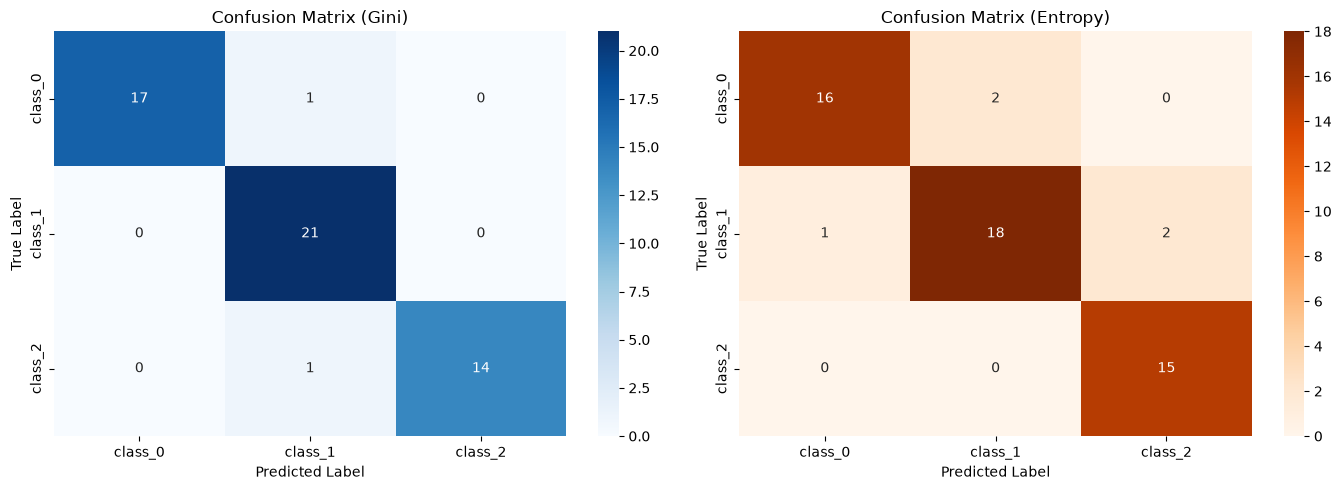

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_gini), annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Gini)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(confusion_matrix(y_test, y_pred_entropy), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Entropy)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Part 6 — Classification Report
Full metric breakdown (Accuracy, Precision, Recall, F1).

In [9]:
print("--- GINI IMPURITY METRICS ---")
print(classification_report(y_test, y_pred_gini, target_names=class_names))

print("\n--- ENTROPY METRICS ---")
print(classification_report(y_test, y_pred_entropy, target_names=class_names))

--- GINI IMPURITY METRICS ---
              precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54


--- ENTROPY METRICS ---
              precision    recall  f1-score   support

     class_0       0.94      0.89      0.91        18
     class_1       0.90      0.86      0.88        21
     class_2       0.88      1.00      0.94        15

    accuracy                           0.91        54
   macro avg       0.91      0.92      0.91        54
weighted avg       0.91      0.91      0.91        54



## Part 7 — Visualize the Decision Trees
Showing the full, unpruned tree structures. Notice how they prioritize different features for their splits.

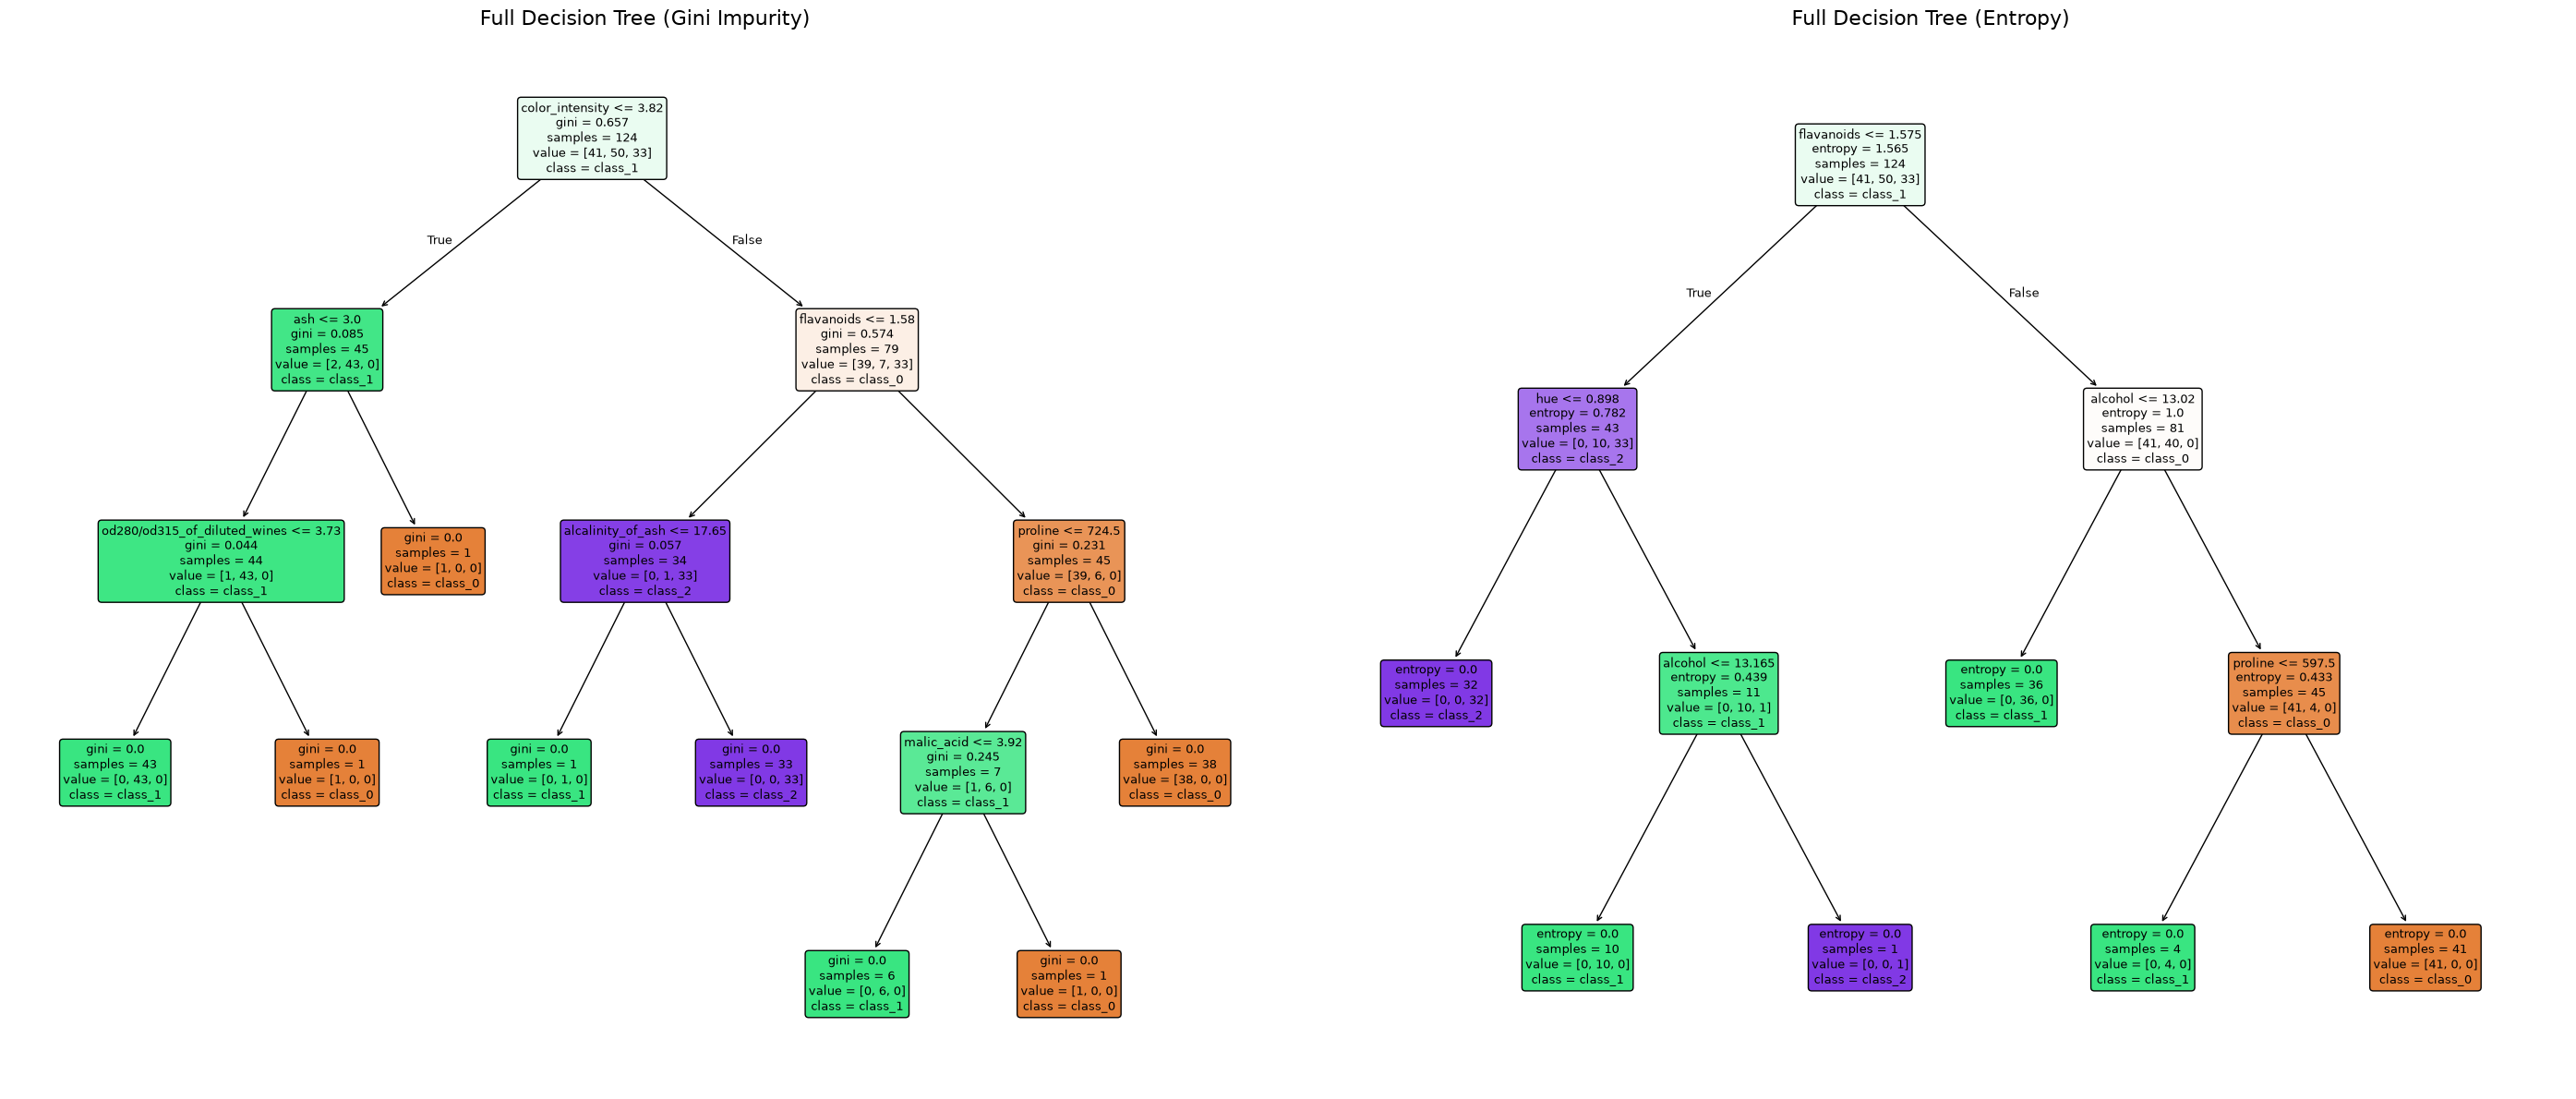

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(28, 12))

plot_tree(clf_gini, feature_names=feature_names, class_names=class_names, 
          filled=True, rounded=True, fontsize=9, ax=axes[0])
axes[0].set_title("Full Decision Tree (Gini Impurity)", fontsize=16)

plot_tree(clf_entropy, feature_names=feature_names, class_names=class_names, 
          filled=True, rounded=True, fontsize=9, ax=axes[1])
axes[1].set_title("Full Decision Tree (Entropy)", fontsize=16)

plt.tight_layout()
plt.show()

## Part 8 — Feature Importance & Information Gain Graphs
First, we plot the intrinsic Feature Importances for both trees. Then, we manually calculate and visualize the **Information Gain** (in bits) for every feature to see how much entropy drops if we split the root node using the median of that feature.

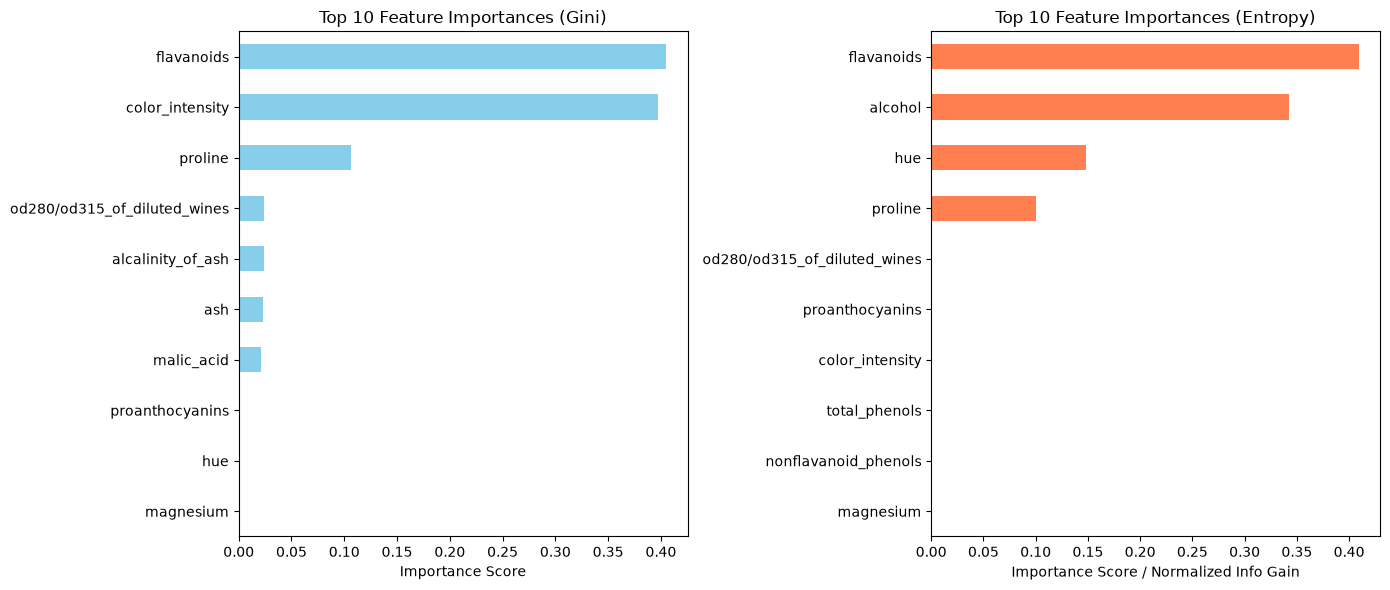

In [11]:
# Plot 1: Standard Feature Importances from the trained trees
importances_gini = pd.Series(clf_gini.feature_importances_, index=feature_names).sort_values(ascending=True)
importances_entropy = pd.Series(clf_entropy.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importances_gini.tail(10).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title("Top 10 Feature Importances (Gini)")
axes[0].set_xlabel("Importance Score")

importances_entropy.tail(10).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title("Top 10 Feature Importances (Entropy)")
axes[1].set_xlabel("Importance Score / Normalized Info Gain")

plt.tight_layout()
plt.show()

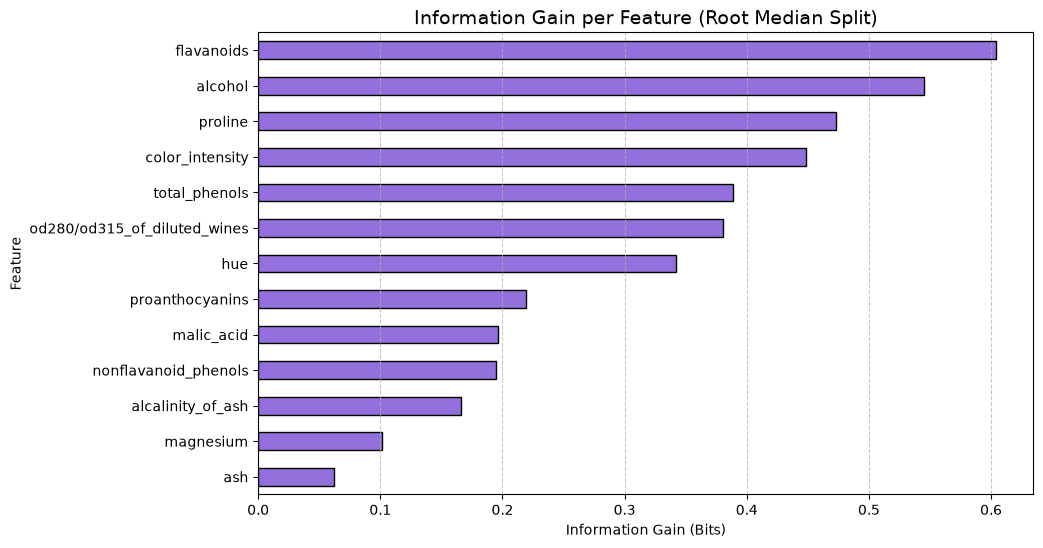

In [12]:
# Plot 2: Explicit Information Gain Graph
# Calculate Root Information Gain for each feature using a median threshold split
base_entropy = entropy(y_train)
info_gains = {}

X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

for i, col in enumerate(feature_names):
    thresh = np.median(X_train_np[:, i])
    left_mask = X_train_np[:, i] <= thresh
    
    left_y = y_train_np[left_mask]
    right_y = y_train_np[~left_mask]
    
    ent_left = entropy(left_y)
    ent_right = entropy(right_y)
    
    w_left = len(left_y) / len(y_train_np)
    w_right = len(right_y) / len(y_train_np)
    
    ig = base_entropy - (w_left * ent_left + w_right * ent_right)
    info_gains[col] = ig

ig_df = pd.Series(info_gains).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ig_df.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.title("Information Gain per Feature (Root Median Split)", fontsize=14)
plt.xlabel("Information Gain (Bits)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Part 9 — Accuracy vs. Tree Depth
Testing both models across different maximum depths to observe where they overfit the training data.

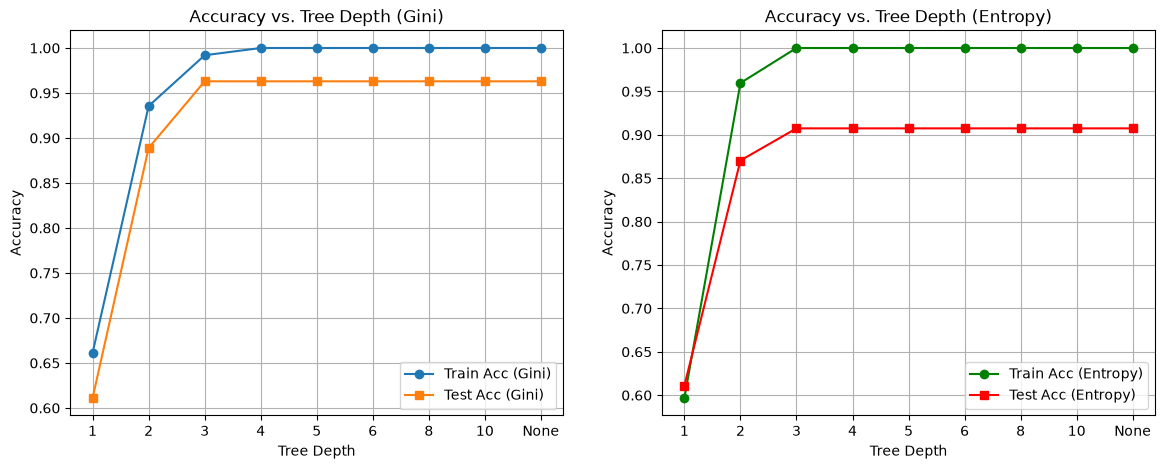

In [13]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_acc_gini, test_acc_gini = [], []
train_acc_ent, test_acc_ent = [], []

for depth in depths:
    # Gini
    dt_g = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt_g.fit(X_train, y_train)
    train_acc_gini.append(accuracy_score(y_train, dt_g.predict(X_train)))
    test_acc_gini.append(accuracy_score(y_test, dt_g.predict(X_test)))
    
    # Entropy
    dt_e = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt_e.fit(X_train, y_train)
    train_acc_ent.append(accuracy_score(y_train, dt_e.predict(X_train)))
    test_acc_ent.append(accuracy_score(y_test, dt_e.predict(X_test)))

depth_labels = [str(d) if d is not None else "None" for d in depths]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depth_labels, train_acc_gini, 'o-', label='Train Acc (Gini)')
axes[0].plot(depth_labels, test_acc_gini, 's-', label='Test Acc (Gini)')
axes[0].set_title("Accuracy vs. Tree Depth (Gini)")
axes[0].set_xlabel("Tree Depth")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(depth_labels, train_acc_ent, 'o-', color='green', label='Train Acc (Entropy)')
axes[1].plot(depth_labels, test_acc_ent, 's-', color='red', label='Test Acc (Entropy)')
axes[1].set_title("Accuracy vs. Tree Depth (Entropy)")
axes[1].set_xlabel("Tree Depth")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.show()

## Part 10 — Result Analysis & Cost-Complexity Pruning
We apply Cost-Complexity Pruning (CCP) to simplify the Gini tree, reducing overfitting while maintaining or improving test accuracy. Finally, we map the pruned tree.

Optimal alpha found: 0.0000
Pruned Tree Test Accuracy: 0.9630
Nodes in original tree: 15
Nodes in pruned tree: 15


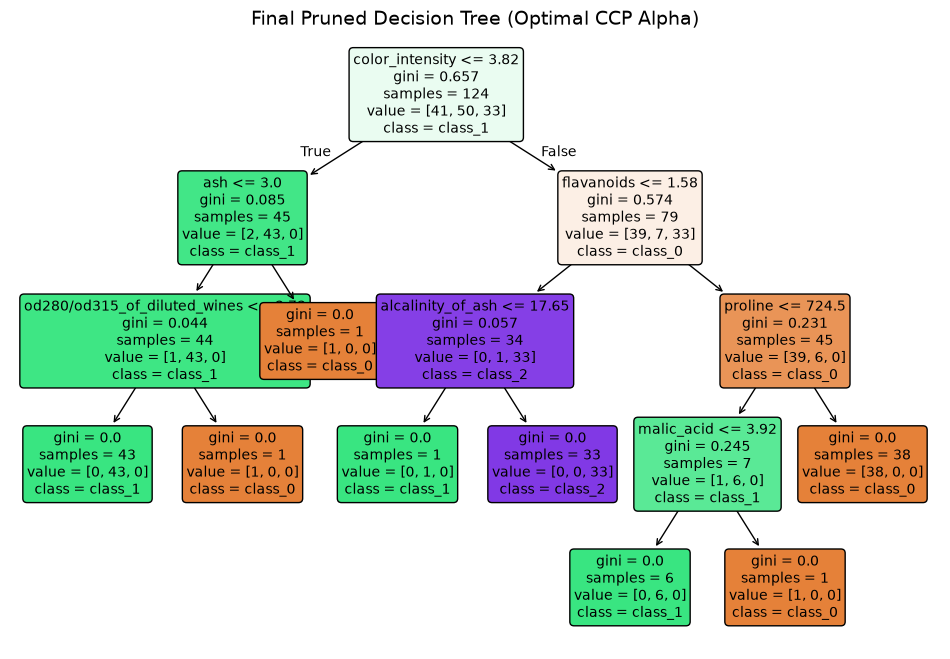

In [14]:
# Get pruning path alphas
path = clf_gini.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Train a tree for each alpha
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Evaluate test accuracy for each pruned tree (excluding the final 1-node trivial tree)
test_scores = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs[:-1]]
best_index = np.argmax(test_scores)
best_clf = clfs[best_index]

print(f"Optimal alpha found: {ccp_alphas[best_index]:.4f}")
print(f"Pruned Tree Test Accuracy: {accuracy_score(y_test, best_clf.predict(X_test)):.4f}")
print(f"Nodes in original tree: {clf_gini.tree_.node_count}")
print(f"Nodes in pruned tree: {best_clf.tree_.node_count}")

# Visualize the Pruned Tree
plt.figure(figsize=(12, 8))
plot_tree(
    best_clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Final Pruned Decision Tree (Optimal CCP Alpha)", fontsize=14)
plt.show()

## Part 11 — Result Analysis
Both the Gini impurity and Entropy criteria were used to train Decision Trees on the Wine dataset. 
- **Performance:** For this dataset, both Gini and Entropy yield similar accuracy scores on the test set. 
- **Splitting Logic:** While accuracy is identical, viewing the Feature Importances (Part 8) and visual trees (Part 7) reveals that the models prioritize splits slightly differently based on their internal math.
- **Overfitting:** The tree depth experiments (Part 9) clearly show that setting `max_depth=None` drives training accuracy to 1.0 (100%), but fails to improve testing accuracy past a certain point, demonstrating classic overfitting.